# **PCD Assignment 2: Image Enhancement**

Ahmad Farhan Hidayat

# Import

In [93]:
from google.colab import drive
drive.mount('/content/drive')

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Image

In [94]:
def load_image(path):
    image = Image.open(path).convert('L')
    return np.array(image, dtype=np.float64)

base_path = '/content/drive/MyDrive/PCD Assignment 2/image/'
output_path = '/content/drive/MyDrive/PCD Assignment 2/result/'

os.makedirs(output_path, exist_ok=True)

dark_image = load_image(base_path + 'dark.jpg')
bright_image = load_image(base_path + 'bright.jpg')
low_contrast_image = load_image(base_path + 'low_contrast.jpg')
blurred_image = load_image(base_path + 'blurred.webp')

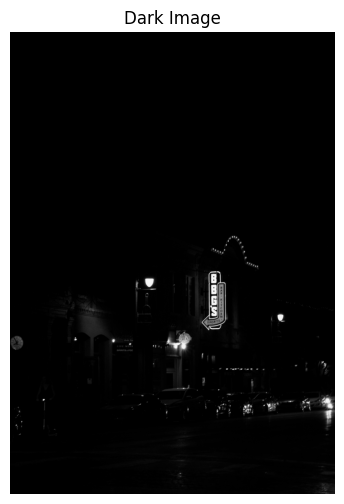

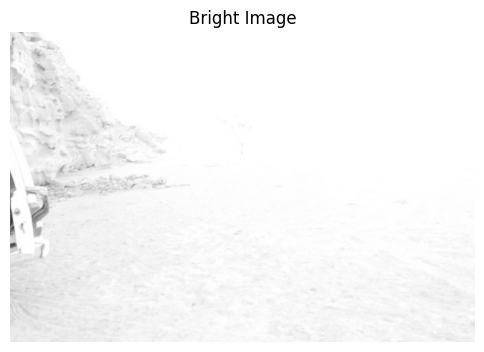

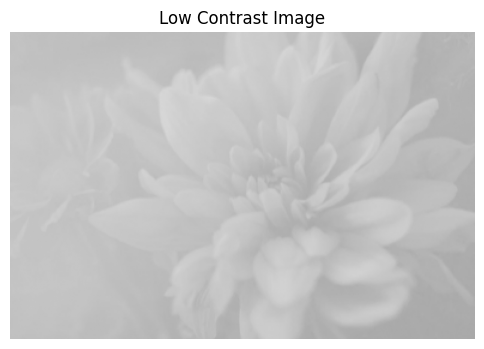

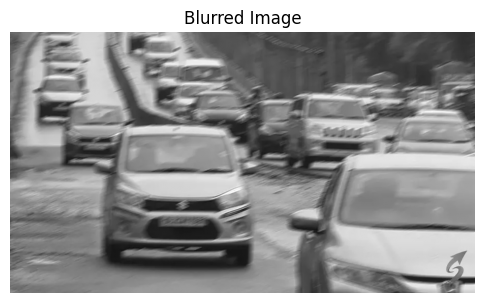

In [95]:
def show_image(image, title='Image'):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

show_image(dark_image, 'Dark Image')
show_image(bright_image, 'Bright Image')
show_image(low_contrast_image, 'Low Contrast Image')
show_image(blurred_image, 'Blurred Image')

# Dark Image - Logarithmic Transform

## Definisi fungsi

In [6]:
def logarithmic_transform(image):
    # Untuk citra 8-bit: L = 256 tingkat intensitas (0-255)
    L = 256

    # Faktor skala agar output berada pada rentang 0-255
    c = (L - 1) / np.log(L)

    # Logarithmic transformation
    output = c * np.log(1 + image)

    # Batasi output pada rentang grayscale
    output = np.clip(output, 0, L - 1)

    return output

## Penerapan enhancement

In [7]:
dark_enhanced = logarithmic_transform(dark_image)

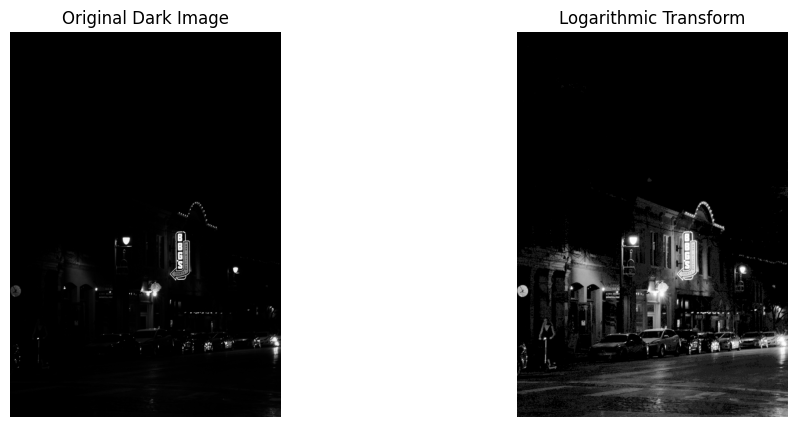

In [72]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(dark_image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Dark Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dark_enhanced, cmap='gray', vmin=0, vmax=255)
plt.title('Logarithmic Transform')
plt.axis('off')

plt.savefig(output_path + 'dark_image_logarithmic_transform.png')
plt.show()

# Bright Image - Gamma Transform

## Definisi fungsi

In [102]:
def gamma_transform(image, gamma, c=1.0):
    # Normalisasi intensitas [0, 255] -> [0, 1]
    r = image / 255.0

    # Power-law transformation: s = c * r^gamma
    s = c * (r ** gamma)

    # Denormalisasi [0, 1] -> [0, 255]
    output = s * 255.0

    # Batasi nilai ke rentang grayscale 8-bit
    output = np.clip(output, 0, 255)

    return output

## Penerapan enhancement

In [103]:
gamma_values = [5.0, 7.0, 10.0]

gamma_results = []

for gamma in gamma_values:
    enhanced = gamma_transform(bright_image, gamma)
    gamma_results.append(enhanced)

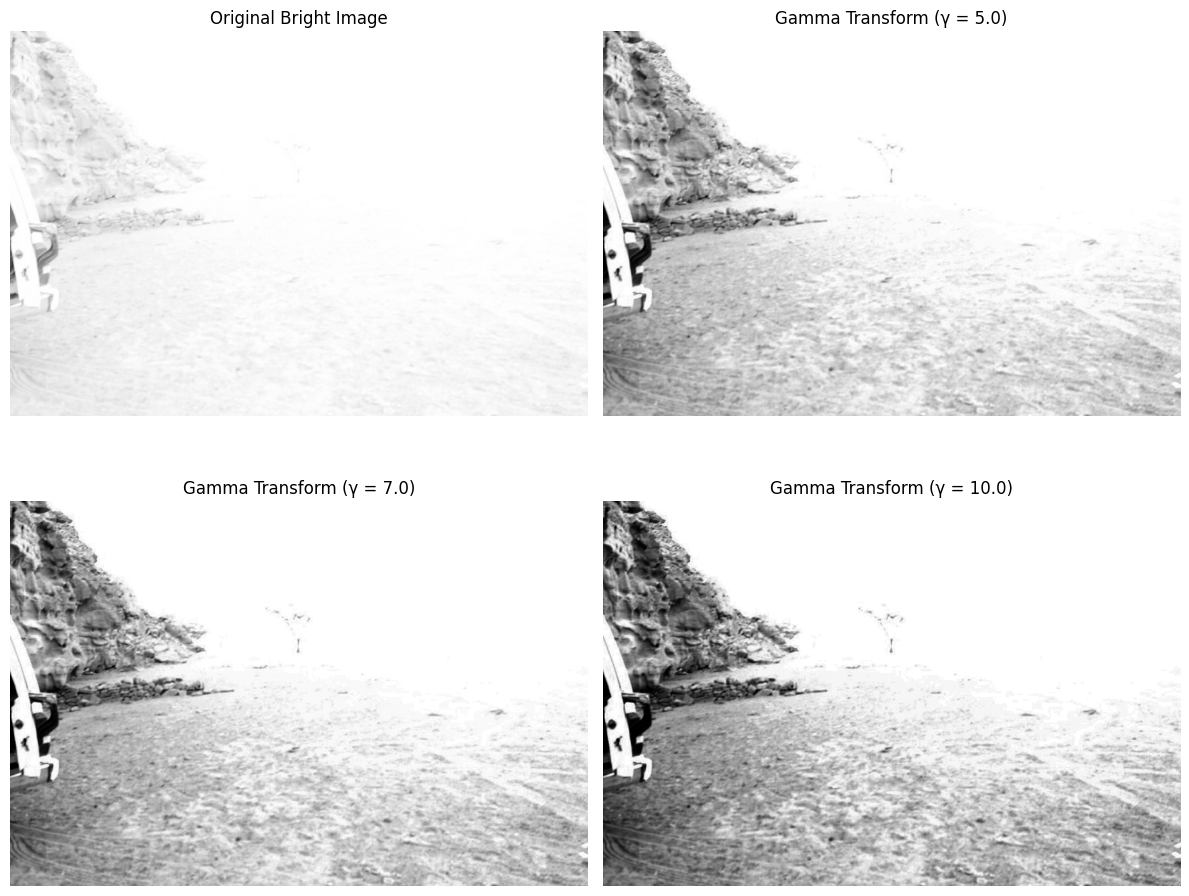

In [104]:
plt.figure(figsize=(12, 10))

# Original
plt.subplot(2, 2, 1)
plt.imshow(bright_image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Bright Image')
plt.axis('off')

# Gamma 5.0
plt.subplot(2, 2, 2)
plt.imshow(gamma_results[0], cmap='gray', vmin=0, vmax=255)
plt.title('Gamma Transform (γ = 5.0)')
plt.axis('off')

# Gamma 7.0
plt.subplot(2, 2, 3)
plt.imshow(gamma_results[1], cmap='gray', vmin=0, vmax=255)
plt.title('Gamma Transform (γ = 7.0)')
plt.axis('off')

# Gamma 10.0
plt.subplot(2, 2, 4)
plt.imshow(gamma_results[2], cmap='gray', vmin=0, vmax=255)
plt.title('Gamma Transform (γ = 10.0)')
plt.axis('off')

plt.tight_layout()
plt.savefig(output_path + 'bright_image_gamma_transform.png')
plt.show()

# Low Contrast Image - Contrast Stretching

## Definisi fungsi

In [96]:
def contrast_stretching(image):
    min_value = np.min(image)
    max_value = np.max(image)

    # Hindari pembagian dengan nol
    if max_value == min_value:
        return image.copy()

    output = (image - min_value) * 255 / (max_value - min_value)

    output = np.clip(output, 0, 255)

    return output

## Penerapan enhancement

In [97]:
print("Minimum :", low_contrast_image.min())
print("Maximum :", low_contrast_image.max())
print("Mean    :", low_contrast_image.mean())
print("Std     :", low_contrast_image.std())

Minimum : 168.0
Maximum : 215.0
Mean    : 192.79787169780928
Std     : 8.954801798726718


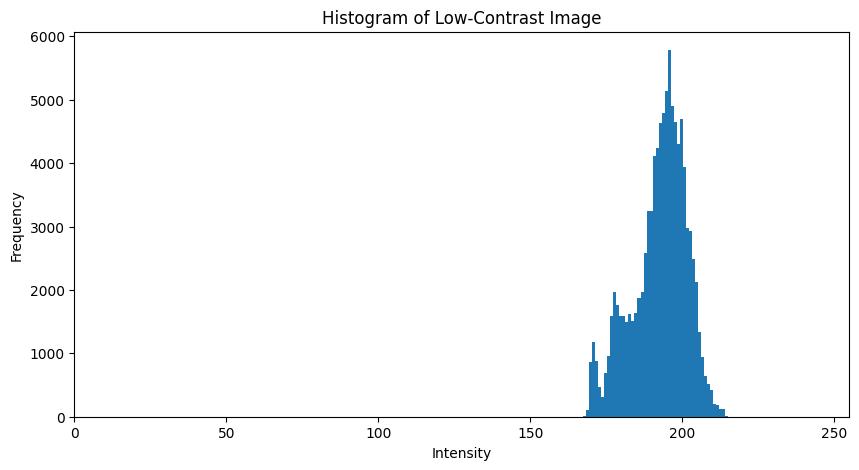

In [98]:
plt.figure(figsize=(10, 5))

plt.hist(
    low_contrast_image.ravel(),
    bins=256,
    range=(0, 255)
)

plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Low-Contrast Image')
plt.xlim(0, 255)
plt.savefig(output_path + 'low-contrast-hist.png')
plt.show()

In [60]:
low_contrast_enhanced = contrast_stretching(low_contrast_image)

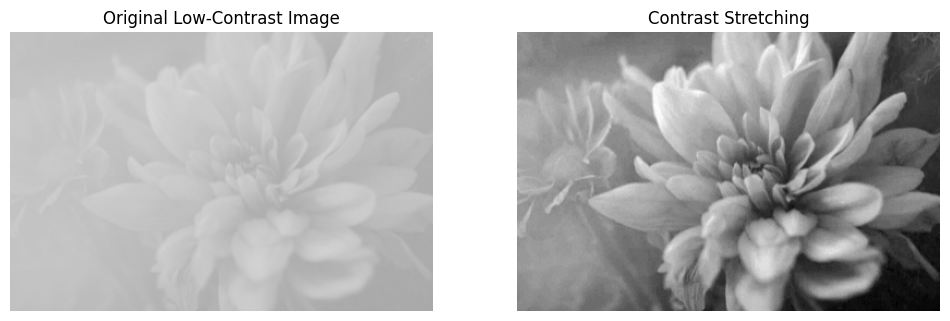

In [99]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(low_contrast_image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Low-Contrast Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(low_contrast_enhanced, cmap='gray', vmin=0, vmax=255)
plt.title('Contrast Stretching')
plt.axis('off')

plt.savefig(output_path + 'low_contrast_image_contrast_stretching.png')
plt.show()

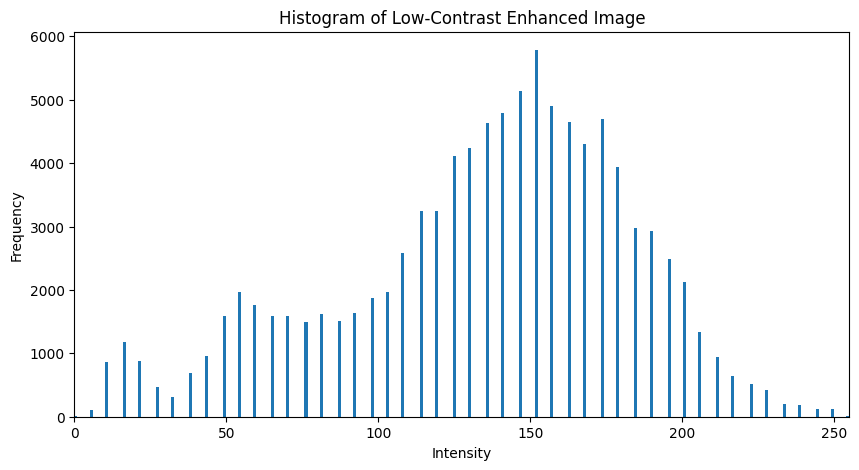

In [100]:
plt.figure(figsize=(10, 5))

plt.hist(
    low_contrast_enhanced.ravel(),
    bins=256,
    range=(0, 255)
)

plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Low-Contrast Enhanced Image')
plt.xlim(0, 255)
plt.savefig(output_path + 'low-contrast-enhanced-hist.png')
plt.show()

In [101]:
print("Minimum :", low_contrast_enhanced.min())
print("Maximum :", low_contrast_enhanced.max())
print("Mean    :", low_contrast_enhanced.mean())
print("Std     :", low_contrast_enhanced.std())

Minimum : 0.0
Maximum : 255.0
Mean    : 134.5416443179014
Std     : 48.584562950538576


# Blurred Image - Laplacian Sharpening

## Definisi fungsi

In [23]:
def convolution(image, kernel):
    height, width = image.shape
    kernel_height, kernel_width = kernel.shape

    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    # Zero-padding
    padded = np.pad(
        image,
        ((pad_height, pad_height),
         (pad_width, pad_width)),
        mode='constant',
        constant_values=0
    )

    output = np.zeros_like(image, dtype=np.float64)

    for i in range(height):
        for j in range(width):
            region = padded[
                i:i + kernel_height,
                j:j + kernel_width
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [24]:
def laplacian_sharpening(image, alpha=1.0):
    # Laplacian kernel
    kernel = np.array([
        [0, -1,  0],
        [-1, 4, -1],
        [0, -1,  0]
    ], dtype=np.float64)

    # Hitung Laplacian
    laplacian = convolution(image, kernel)

    # Sharpening
    output = image + alpha * laplacian

    # Batasi ke rentang grayscale
    output = np.clip(output, 0, 255)

    return output

## Penerapan enhancement

In [29]:
blurred_enhanced = laplacian_sharpening(
    blurred_image,
    alpha=3
)

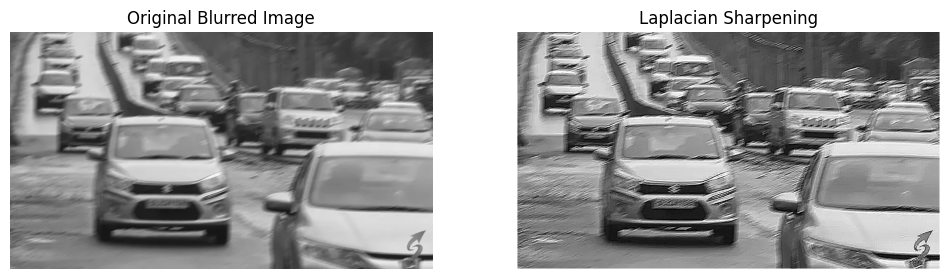

In [75]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(blurred_image, cmap='gray', vmin=0, vmax=255)
plt.title('Original Blurred Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blurred_enhanced, cmap='gray', vmin=0, vmax=255)
plt.title('Laplacian Sharpening')
plt.axis('off')

plt.savefig(output_path + 'blurred_image_laplacian_sharpening.png')
plt.show()